# Pixel inspector

A picture is a grid of numbers: each pixel is three values, red, green, and
blue, each 0-255. Everything below works directly on that grid -- a numpy
array of shape `(height, width, 3)` -- with no wrapper classes in between.


## Section 1 - Pull in necessary libraries 

Before you begin running the code, please open the files on the right hand side and explore what is contained in them.

When working with this program, make sure you run the cells in order from top to bottom. Otherwise you may get errors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from piclab import io_utils, transforms, fast_transforms, encoding

#Specific to Jupyter Notebooks to have all the graphs shown embedded into this page instead of popping up on a new screen.
%matplotlib inline

## Section 2 - Load an image

This gives you back a plain numpy array. `pixels.shape` is
`(height, width, 3)` -- The values are printed using line 10 of the code and displayed below the code. The image is displayed below the information.

shape: (480, 640, 3)


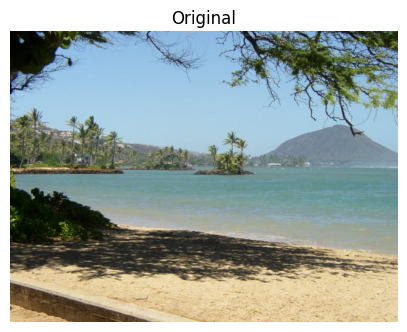

In [2]:
from pathlib import Path

# works whether the notebook's working directory is the repo root
# (VS Code / Codespaces default) or the notebooks/ folder itself
image_path = Path("images/beach.jpg")
if not image_path.exists():
    image_path = Path("../images/beach.jpg")

pixels = io_utils.load_image(image_path)
print("shape:", pixels.shape)

plt.figure(figsize=(5, 4))
plt.imshow(pixels)
plt.axis("off")
plt.title("Original")
plt.show()

## Section 3 - A single pixel, as numbers

Pick any row/col and look at what's actually stored there.

In [14]:
row, col = 1, 1
rgb = transforms.get_pixel(pixels, row, col)
print("RGB:   ", rgb)
print("hex:   ", encoding.to_hex(rgb))
print("binary:", encoding.to_binary(rgb))

RGB:    (2, 4, 1)
hex:    #020401
binary: 00000010 00000100 00000001


## Section 4 - Pixel grid inspector (interactive)

Choose a small region of the image. Instead of seeing it as a photo, you'll
see it as what it actually is: a grid of colored cells, each labeled with its
own R, G, B values. Drag the red/green/blue sliders and watch the selected
region (and the full picture) update live -- same array, same numbers,
different view.

In [3]:
region_size = 8

def show_inspector(row0=40, col0=60, red_delta=0, green_delta=0, blue_delta=0):
    edited = pixels.copy()
    region = edited[row0:row0 + region_size, col0:col0 + region_size].astype(int)
    region[:, :, 0] = np.clip(region[:, :, 0] + red_delta, 0, 255)
    region[:, :, 1] = np.clip(region[:, :, 1] + green_delta, 0, 255)
    region[:, :, 2] = np.clip(region[:, :, 2] + blue_delta, 0, 255)
    edited[row0:row0 + region_size, col0:col0 + region_size] = region.astype(np.uint8)

    fig, (ax_full, ax_grid) = plt.subplots(1, 2, figsize=(10, 4.5))

    ax_full.imshow(edited)
    ax_full.add_patch(plt.Rectangle((col0, row0), region_size, region_size,
                                     fill=False, edgecolor="yellow", linewidth=2))
    ax_full.set_title("Full image")
    ax_full.axis("off")

    grid = edited[row0:row0 + region_size, col0:col0 + region_size]
    ax_grid.imshow(grid, interpolation="nearest")
    for r in range(region_size):
        for c in range(region_size):
            rr, gg, bb = grid[r, c]
            text_color = "white" if int(rr) + int(gg) + int(bb) < 380 else "black"
            ax_grid.text(c, r, f"{rr}\n{gg}\n{bb}", ha="center", va="center",
                         fontsize=6, color=text_color)
    ax_grid.set_title(f"Zoomed region ({region_size}x{region_size} pixels)")
    ax_grid.set_xticks([]); ax_grid.set_yticks([])

    plt.tight_layout()
    plt.show()

interact(
    show_inspector,
    row0=widgets.IntSlider(min=0, max=max(pixels.shape[0] - region_size, 1), step=1, value=40),
    col0=widgets.IntSlider(min=0, max=max(pixels.shape[1] - region_size, 1), step=1, value=60),
    red_delta=widgets.IntSlider(min=-255, max=255, step=1, value=0),
    green_delta=widgets.IntSlider(min=-255, max=255, step=1, value=0),
    blue_delta=widgets.IntSlider(min=-255, max=255, step=1, value=0),
);

interactive(children=(IntSlider(value=40, description='row0', max=472), IntSlider(value=60, description='col0'…

## Whole-image transforms

The same functions students edit for the lab, run on the whole array.

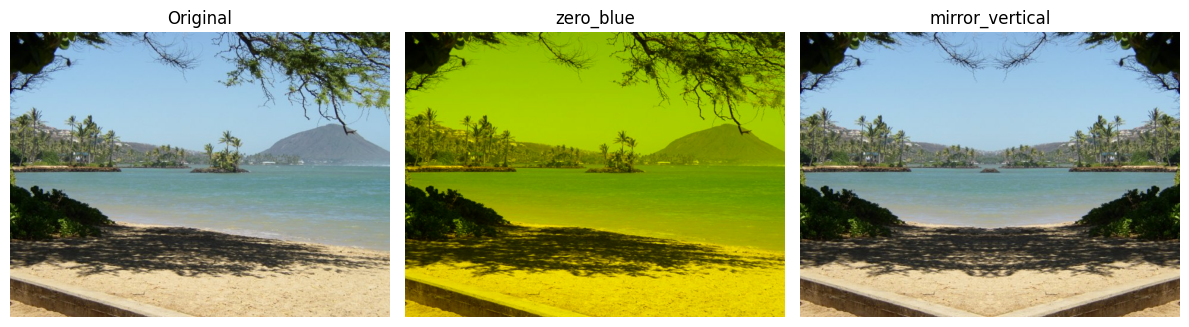

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(transforms.zero_blue(pixels)); axes[1].set_title("zero_blue"); axes[1].axis("off")
axes[2].imshow(transforms.mirror_vertical(pixels)); axes[2].set_title("mirror_vertical"); axes[2].axis("off")
plt.tight_layout()
plt.show()

## Edge detection, with a live threshold slider

`edge_dist` is how different two neighboring pixels' colors have to be
before we call it an edge. Drag it and watch which edges appear or
disappear.

In [6]:
def show_edges(edge_dist=20):
    result = fast_transforms.edge_detection(pixels, edge_dist)
    plt.figure(figsize=(5, 4))
    plt.imshow(result)
    plt.axis("off")
    plt.title(f"edge_dist = {edge_dist}")
    plt.show()

interact(show_edges, edge_dist=widgets.IntSlider(min=0, max=200, step=5, value=20));

interactive(children=(IntSlider(value=20, description='edge_dist', max=200, step=5), Output()), _dom_classes=(…

## Your turn

1. Open `src/piclab/transforms.py` and read `zero_blue`. Write a `zero_red`
   next to it the same way, then import and try it above.
2. Compare `transforms.zero_blue` (loop-based) to `fast_transforms.zero_blue`
   (vectorized). Time both on a large image with `%timeit` -- how much
   faster is the vectorized version, and why?
3. Modify `mirror_region` to mirror top-to-bottom instead of left-to-right.